# Mini Data Science Project: Genshin Impact Artifacts

## 1. Dataset selection

We use a simulated dataset of **1,000,000 Artifacts** from the game Genshin Impact. Each artifact was tracked at levels 0, 4, 8, 12, 16 and 20, so the table has **6,000,000 rows** (one row per snapshot).

### What each column means

| Column | Meaning |
|---|---|
| `artifact_id` | Which artifact this snapshot belongs to |
| `level` | Upgrade level (0, 4, 8, 12, 16, 20) |
| `slot`, `main_stat`, `sub_count` | Piece type and how many bonus stats it has |
| `cv` | Crit Value right now (see formula below) |
| `has_crit_rate`, `has_crit_dmg` | Has those prized crit stats yet? (1 = yes, 0 = no) |
| `final_cv` | CV at level 20 (the target we want to predict) |

Crit Value formula:

$$ \text{CV} = 2 \times \text{Crit Rate\%} + \text{Crit Damage\%} $$

## 2. What is an Artifact?

Artifacts are gear pieces you level up from 0 to 20. Every 4 levels one random bonus stat gets stronger. Players want high Crit Value because it means more damage.

### Example: leveling a Flower

| Stat | Level 0 (start) | Level 20 (finished) |
|---|---|---|
| HP | +269 | +538 (1 upgrade) |
| ATK | +4.1% | +4.1% (no upgrade) |
| Crit Rate | +3.9% | +10.5% (2 upgrades) |
| Crit Damage | +7.8% | +21.8% (2 upgrades) |

How the CV adds up:

- Starting: $\text{CV}_0 = 2 \times 3.9 + 7.8 = 15.6$

- Final: $\text{CV}_{20} = 2 \times 10.5 + 21.8 = 42.8$

**Our questions:**

1. Can we guess the final CV from the starting stats at level 0?
2. Can we spot a *keeper* early - an artifact that will finish in the top 10%?
3. Can we group finished artifacts into simple quality tiers (needs work / good / exceptional)?


## 3. Data preparation

We load the data, check for gaps, look at the first rows and averages, then split off level 0 (for guessing the final number) and level 20 (for defining keepers and tiers). We split by `artifact_id` later so the same artifact never appears in both training and testing.

Cleaning checklist (assignment §3): missing values → `isnull().sum()` below (result: none, so no imputation needed); types → all numeric; ready splits → level 0 for regression/classification, level 20 for keeper line and clustering.

Technique map (assignment §2): §5 = Linear Regression, §6 = Classification (Logistic Regression + Random Forest), §7 = Clustering (K-means).


Rows: 6,000,000, Artifacts: 1,000,000
<class 'pandas.DataFrame'>
RangeIndex: 6000000 entries, 0 to 5999999
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   artifact_id    int64  
 1   level          int64  
 2   slot           int64  
 3   main_stat      int64  
 4   sub_count      int64  
 5   cv             float64
 6   has_crit_rate  int64  
 7   has_crit_dmg   int64  
 8   final_cv       float64
dtypes: float64(2), int64(7)
memory usage: 412.0 MB


None

artifact_id      0
level            0
slot             0
main_stat        0
sub_count        0
cv               0
has_crit_rate    0
has_crit_dmg     0
final_cv         0
dtype: int64

,artifact_id,level,slot,main_stat,sub_count,cv,has_crit_rate,has_crit_dmg,final_cv
0,0,0,0,7,3,6.99,0,1,26.42
1,0,4,0,7,4,13.99,1,1,26.42
2,0,8,0,7,4,13.99,1,1,26.42
3,0,12,0,7,4,20.98,1,1,26.42
4,0,16,0,7,4,26.42,1,1,26.42


,artifact_id,level,slot,main_stat,sub_count,cv,has_crit_rate,has_crit_dmg,final_cv
count,"6,000,000.00","6,000,000.00","6,000,000.00","6,000,000.00","6,000,000.00","6,000,000.00","6,000,000.00","6,000,000.00","6,000,000.00"
mean,"499,999.50",10.00,2.00,6.35,3.87,6.09,0.31,0.31,8.77
std,"288,675.16",6.83,1.41,3.13,0.34,7.20,0.46,0.46,9.68
min,0.00,0.00,0.00,0.00,3.00,0.00,0.00,0.00,0.00
25%,"249,999.75",4.00,1.00,5.00,4.00,0.00,0.00,0.00,0.00
50%,"499,999.50",10.00,2.00,6.00,4.00,5.44,0.00,0.00,6.22
75%,"749,999.25",16.00,3.00,7.00,4.00,7.78,1.00,1.00,14.76
max,"999,999.00",20.00,4.00,18.00,4.00,54.43,1.00,1.00,54.43


level
0     1000000
4     1000000
8     1000000
12    1000000
16    1000000
20    1000000

Level 0 rows: 1,000,000
Level 20 rows: 1,000,000

Keeper means final CV >= 21.78 (top 10% at level 20)
Keepers in total table: 605,946 out of 6,000,000
Anomalies (final CV > 40): 3,395 out of 1,000,000 finished (0.34%)


## 4. First look at the data

Most finished artifacts are weak. Only a small slice on the right side of the chart counts as a keeper. On average CV grows steadily with each upgrade, but luck matters a lot.


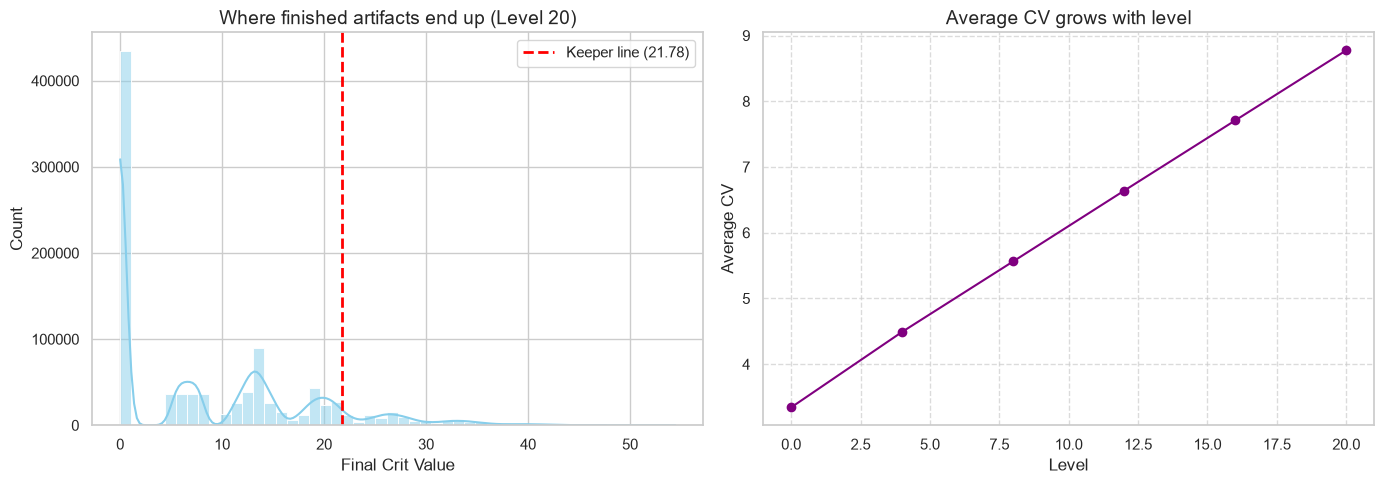

## 5. Technique 1: Linear Regression — guessing the final number

We start simple. Using only what we see at level 0 (`cv`, `sub_count`, and whether crit stats are present), we make one straight-line guess at the final score.

Think of it as:

starting stats $\rightarrow$ one guessed final number

How we judge the guesses:

- How far off are we on average, in CV points? (called $\text{RMSE}$)

- How much of the gap between good and bad artifacts do we capture? (called $R^2$, where 0 = nothing and 1 = perfect)

Note: starting CV already includes crit info, so the two yes/no crit flags add only a little on top. We leave out `slot` and `main_stat` here to keep things easy to explain.


MSE: 41.16  |  RMSE: 6.42  |  R2: 0.56
On average our guess is off by about 6.4 CV points.

What the model learned (higher = pushes guess up):
  sub_count: -1.136
  cv: 0.999
  has_crit_rate: 5.761
  has_crit_dmg: 5.732
  starting point: 6.16


An $R^2$ around 0.5 means the starting stats explain about half the story. The rest is luck during upgrades, so no level 0 guess can be perfect.


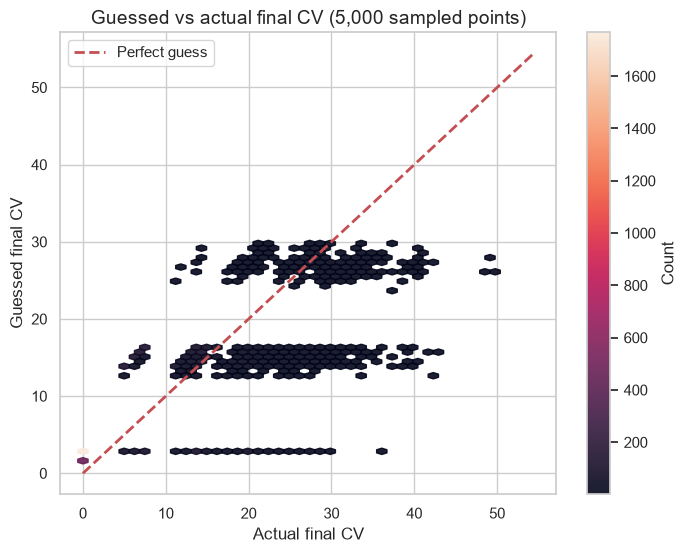

## 6. Technique 2: Classification — keep or toss? (the keeper test)

Players do not need the exact final number. They need a yes/no answer: *is this worth leveling?*

We call the top 10% keepers. The cutoff sits around 21.8 CV.

Then at each level (0, 4, 8, 12, 16) we compare three classifiers:

- **Current CV only (baseline)** - just trust what you see now.

- **Classification: Logistic Regression** - one weight per stat, added up (simple weighted score).

- **Classification: Random Forest** - many small rules vote together (tree vote).

How we judge it:

- Ranking quality (called $AUC$): 0.5 = guessing, 1.0 = perfect.

- When it says keeper, how often is it right? And how many real keepers does it find?

We split by artifact ID so the same artifact is never in both training and testing. We sample 100k training rows per level so the notebook runs fast - results match full data within a point or two.


Level  | Base AUC  | LogReg AUC  | Forest AUC | Forest Prec | Forest Recal
--------------------------------------------------------------------------------


+0     | 0.8410    | 0.8432      | 0.8445     | 0.7459      | 0.3599


+4     | 0.9138    | 0.9169      | 0.9168     | 0.7344      | 0.6186


+8     | 0.9422    | 0.9501      | 0.9502     | 0.7468      | 0.6246


+12    | 0.9660    | 0.9704      | 0.9707     | 0.8575      | 0.6111


+16    | 0.9843    | 0.9855      | 0.9872     | 0.8901      | 0.7416


,level,baseline,logreg,forest,prec,rec
0,0,0.84,0.84,0.84,0.75,0.36
1,4,0.91,0.92,0.92,0.73,0.62
2,8,0.94,0.95,0.95,0.75,0.62
3,12,0.97,0.97,0.97,0.86,0.61
4,16,0.98,0.99,0.99,0.89,0.74


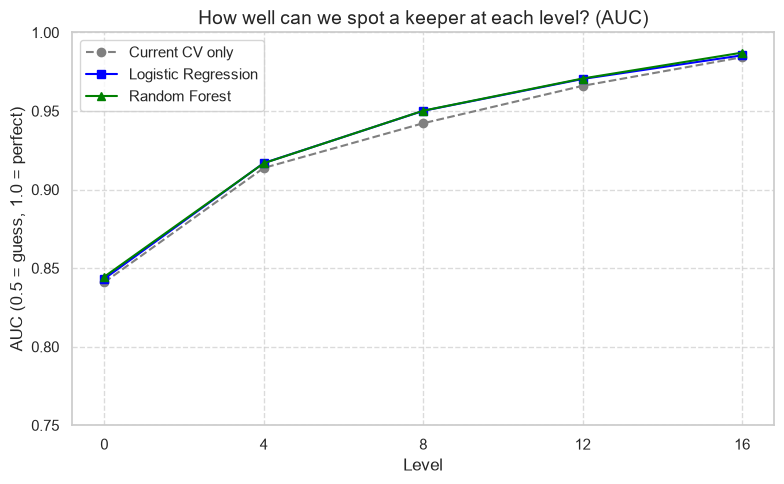

## 7. Technique 3: Clustering (K-means) — grouping finished artifacts

We group finished artifacts by final CV into 3 tiers: needs-work, good, and exceptional.

We use CV only because `sub_count` at level 20 is almost always 4, so it does not help separate groups. Values are rescaled first so the grouping is fair, then centers are converted back to real CV.


Tier centers (real CV):
  Tier 0: ~1.7 CV
  Tier 1: ~15.6 CV
  Tier 2: ~28.9 CV

Counts per tier:
tier
0    579575
1    324682
2     95743

Meaning: {0: 'Needs work', 1: 'Good', 2: 'Exceptional'}


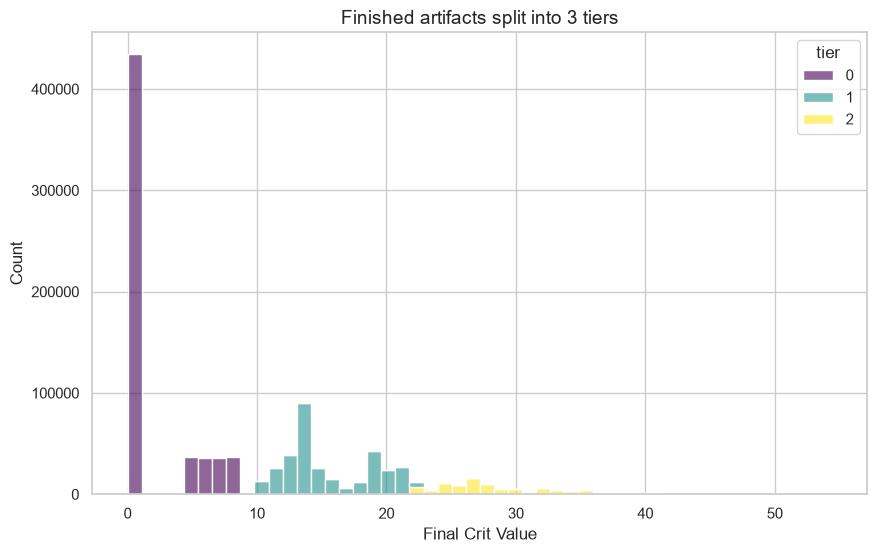

## 8. What we found (for the presentation)

- **Most artifacts finish weak.** Average finished CV is about 8.8, middle value is about 6.2. The keeper line sits around 21.8. Anything above 40 is very rare and very valuable.
- **Starting stats help but luck matters.** Guessing from level 0 is off by about 6-7 points on average and captures about half the gap between good and bad pieces.
- **Keep-or-toss gets safer as you level.** Current CV alone already ranks well (about 0.83 at level 0, about 0.98 at level 16 on a 0.5-to-1.0 scale). The tree vote is a little better early on. Practical rule: be strict early, trust the call from level 12 on.
- **Three clear tiers.** Finished pieces split into needs-work (low CV bulk), good (middle), and exceptional (keeper zone on the right).

### Limits and next steps
- This data is simulated to mimic game odds, not pulled from real accounts, so real drop rates may differ.
- We kept the models simple on purpose (`cv` + 3 helper columns). Adding `slot` and `main_stat` or trying per-level thresholds is an easy follow-up.
- For players: do not throw away everything early (level 0 calls still miss). Re-check at 8-12 before deciding.
